In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import RandomOverSampler, SMOTE

pd.set_option('display.max_columns', 100)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

## Load data

In [3]:
# Load datasets
kyc = pd.read_csv("./kyc.csv")
wire = pd.read_csv("./wire_trxns.csv")
emt = pd.read_csv("./emt_trxns.csv")
cash = pd.read_csv("./cash_trxns.csv")

print("KYC shape:", kyc.shape)
print("Wire shape:", wire.shape)
print("EMT shape:", emt.shape)
print("Cash shape:", cash.shape)

KYC shape: (195789, 7)
Wire shape: (67872, 8)
EMT shape: (506451, 7)
Cash shape: (212532, 4)


In [5]:
kyc.head()

,Name,Gender,Occupation,Age,Tenure,cust_id,label
0,JENNIFER WELLS,female,Architect,45.0,13.0,CUST82758793,0
1,ANTHONY ADAMS,male,Musician,52.0,8.0,CUST69248708,0
2,DENISE LEWIS,female,Jewelry Dealer,43.0,11.0,CUST67222818,0
3,STEPHEN FIGUEROA,male,Optometrist,35.0,17.0,CUST33995820,0
4,KYLE EDWARDS,male,Real Estate Broker,39.0,21.0,CUST76401392,1


In [7]:
wire.head()

,id sender,id receiver,name sender,name receiver,wire value,country sender,country receiver,trxn_id
0,EXTERNAL753550,CUST30139466,CHEN MIN,DESTINY MOORE,10098.0,CN,CA,TKEV83070517
1,CUST43146787,CUST94438297,DR. BENJAMÍN PAREDES,BOBBY SERRANO,1267.0,CA,CA,LWCS42954834
2,CUST82396415,EXTERNAL842611,WHITNEY WRIGHT,VICTORIA HOGAN,8591.0,CA,US,NTTG55749308
3,EXTERNAL851271,CUST84545757,DR.TRACY MOODY,MINDY BURGESS,1480.5,CA,CA,IXVD84599097
4,EXTERNAL685849,CUST14982223,JEREMY WHITE,NITARA BARMAN,13310.0,AU,CA,TIGB41956889


In [9]:
emt.head()

,id sender,id receiver,name sender,name receiver,emt message,emt value,trxn_id
0,CUST26232205,CUST94681618,JASON GARRISON,RENEE LANG,for the bike u lent me,154.0,WFEZ76031047
1,EXTERNAL623153,CUST59533929,GINA WISE,BRIAN HAMILTON,NaN,1170.5,RAUG63886259
2,CUST35533148,CUST23126187,ANTHONY ROBERSON,NICHOLAS DODSON,NaN,518.0,XQJS86205330
3,CUST59096559,EXTERNAL470507,KEVIN PARK,FREDERICK CARPENTER,NaN,46.0,WPXP45854083
4,CUST69049633,EXTERNAL818528,ZHU FENG LAN,ROMIL LANKA,NaN,570.0,OIRZ70883325


In [11]:
cash.head()

,cust_id,amount,type,trxn_id
0,CUST69827909,2330,deposit,XFMC87396884
1,CUST78509707,4800,deposit,BFMG48785876
2,CUST71480951,6510,withdrawal,TIAX63158064
3,CUST70854140,1715,deposit,IVIV63658514
4,CUST57406487,3770,withdrawal,TCBO25660159


## EDA

In [13]:
def overview(df, name):
    print(f"\n===== {name} =====")
    print(df.info())
    print("\nMissing values:")
    print(df.isnull().sum().sort_values(ascending=False).head(10))
    print("\nDuplicates:", df.duplicated().sum())

overview(kyc, "KYC")
overview(wire, "WIRE")
overview(emt, "EMT")
overview(cash, "CASH")


===== KYC =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195789 entries, 0 to 195788
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Name        195789 non-null  object 
 1   Gender      195789 non-null  object 
 2   Occupation  195789 non-null  object 
 3   Age         195789 non-null  float64
 4   Tenure      195789 non-null  float64
 5   cust_id     195789 non-null  object 
 6   label       195789 non-null  int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 10.5+ MB
None

Missing values:
Name          0
Gender        0
Occupation    0
Age           0
Tenure        0
cust_id       0
label         0
dtype: int64

Duplicates: 0

===== WIRE =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67872 entries, 0 to 67871
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id sender         67872 non-null  object 
 1 

In [21]:
kyc["label"].value_counts(normalize=True)

label
0    0.971837
1    0.028163
Name: proportion, dtype: float64

In [23]:
def standardize_wire(df):
    out = pd.DataFrame({
        "trxn_id": df["trxn_id"],
        "txn_type": "wire",
        "amount": df["wire value"],
        "sender_id": df["id sender"],
        "receiver_id": df["id receiver"],
        "sender_country": df["country sender"],
        "receiver_country": df["country receiver"],
        "message": np.nan,
        "cash_type": np.nan,
        "cust_id": np.nan,     # not used for 2-party tables
    })
    return out

def standardize_emt(df):
    out = pd.DataFrame({
        "trxn_id": df["trxn_id"],
        "txn_type": "emt",
        "amount": df["emt value"],
        "sender_id": df["id sender"],
        "receiver_id": df["id receiver"],
        "sender_country": np.nan,
        "receiver_country": np.nan,
        "message": df["emt message"],
        "cash_type": np.nan,
        "cust_id": np.nan,
    })
    return out

def standardize_cash(df):
    out = pd.DataFrame({
        "trxn_id": df["trxn_id"],
        "txn_type": "cash",
        "amount": df["amount"],
        "sender_id": np.nan,
        "receiver_id": np.nan,
        "sender_country": np.nan,
        "receiver_country": np.nan,
        "message": np.nan,
        "cash_type": df["type"],   # deposit / withdrawal
        "cust_id": df["cust_id"],  # single party customer
    })
    return out

wire_std = standardize_wire(wire)
emt_std  = standardize_emt(emt)
cash_std = standardize_cash(cash)

transactions = pd.concat([wire_std, emt_std, cash_std], ignore_index=True)

print("transactions:", transactions.shape)
transactions.head()

transactions: (786855, 10)


,trxn_id,txn_type,amount,sender_id,receiver_id,sender_country,receiver_country,message,cash_type,cust_id
0,TKEV83070517,wire,10098.0,EXTERNAL753550,CUST30139466,CN,CA,NaN,NaN,NaN
1,LWCS42954834,wire,1267.0,CUST43146787,CUST94438297,CA,CA,NaN,NaN,NaN
2,NTTG55749308,wire,8591.0,CUST82396415,EXTERNAL842611,CA,US,NaN,NaN,NaN
3,IXVD84599097,wire,1480.5,EXTERNAL851271,CUST84545757,CA,CA,NaN,NaN,NaN
4,TIGB41956889,wire,13310.0,EXTERNAL685849,CUST14982223,AU,CA,NaN,NaN,NaN


Merge and 

In [25]:
# sender-side rows for wire/emt
sender_side = transactions[transactions["txn_type"].isin(["wire","emt"])].copy()
sender_side["cust_id_actor"] = sender_side["sender_id"]
sender_side["role"] = "sender"

# receiver-side rows for wire/emt
receiver_side = transactions[transactions["txn_type"].isin(["wire","emt"])].copy()
receiver_side["cust_id_actor"] = receiver_side["receiver_id"]
receiver_side["role"] = "receiver"

# cash rows already have cust_id
cash_side = transactions[transactions["txn_type"].eq("cash")].copy()
cash_side["cust_id_actor"] = cash_side["cust_id"]
cash_side["role"] = cash_side["cash_type"].fillna("cash")

actor_txns = pd.concat([sender_side, receiver_side, cash_side], ignore_index=True)

# keep only internal customers so we can join to KYC label
actor_txns = actor_txns[actor_txns["cust_id_actor"].astype(str).str.startswith("CUST")].copy()

print("actor_txns:", actor_txns.shape)
actor_txns.head()

actor_txns: (1003065, 12)


,trxn_id,txn_type,amount,sender_id,receiver_id,sender_country,receiver_country,message,cash_type,cust_id,cust_id_actor,role
1,LWCS42954834,wire,1267.0,CUST43146787,CUST94438297,CA,CA,NaN,NaN,NaN,CUST43146787,sender
2,NTTG55749308,wire,8591.0,CUST82396415,EXTERNAL842611,CA,US,NaN,NaN,NaN,CUST82396415,sender
5,SLBV29462341,wire,1587.0,CUST61153056,EXTERNAL567325,CA,CA,NaN,NaN,NaN,CUST61153056,sender
6,ERLU26785367,wire,1546.0,CUST93918261,CUST16525706,CA,CA,NaN,NaN,NaN,CUST93918261,sender
7,STZX92186222,wire,2503.5,CUST13916601,EXTERNAL727496,CA,CA,NaN,NaN,NaN,CUST13916601,sender


In [31]:
data = actor_txns

Basic Volume & Intensity Features

In [29]:
customer_features = actor_txns.groupby("cust_id_actor").agg(
    
    # Overall activity
    total_amount=("amount","sum"),
    avg_amount=("amount","mean"),
    std_amount=("amount","std"),
    max_amount=("amount","max"),
    txn_count=("amount","count"),
    
    # Transaction types
    wire_count=("txn_type", lambda x: (x=="wire").sum()),
    emt_count=("txn_type", lambda x: (x=="emt").sum()),
    cash_count=("txn_type", lambda x: (x=="cash").sum()),
    
).reset_index()

Directional Behavior

In [37]:
directional = data.groupby("cust_id_actor").agg(
    
    sent_amount=("amount", lambda x: x[data.loc[x.index,"role"]=="sender"].sum()),
    received_amount=("amount", lambda x: x[data.loc[x.index,"role"]=="receiver"].sum()),
    
    sent_count=("role", lambda x: (x=="sender").sum()),
    received_count=("role", lambda x: (x=="receiver").sum()),
    
).reset_index()

customer_features = customer_features.merge(
    directional, on="cust_id_actor", how="left"
)

Counterparty risk

In [42]:
# For sender: count unique receivers
unique_receivers = (
    data[data["role"]=="sender"]
    .groupby("cust_id_actor")["receiver_id"]
    .nunique()
    .reset_index(name="unique_receivers")
)

# For receiver: count unique senders
unique_senders = (
    data[data["role"]=="receiver"]
    .groupby("cust_id_actor")["sender_id"]
    .nunique()
    .reset_index(name="unique_senders")
)

customer_features = customer_features.merge(unique_receivers, on="cust_id_actor", how="left")
customer_features = customer_features.merge(unique_senders, on="cust_id_actor", how="left")

External exposure

In [49]:
data["external_flag"] = (
    data["sender_id"].astype(str).str.startswith("EXTERNAL") |
    data["receiver_id"].astype(str).str.startswith("EXTERNAL")
)

external_features = data.groupby("cust_id_actor").agg(
    external_txn_count=("external_flag","sum")
).reset_index()

customer_features = customer_features.merge(external_features, on="cust_id_actor", how="left")

High risk country exposure

In [55]:
high_risk_countries = ["RU","CN","IN", "SA"]  # example

data["high_risk_country"] = (
    data["sender_country"].isin(high_risk_countries) |
    data["receiver_country"].isin(high_risk_countries)
)

country_features = data.groupby("cust_id_actor").agg(
    high_risk_country_txn=("high_risk_country","sum")
).reset_index()

customer_features = customer_features.merge(country_features, on="cust_id_actor", how="left")

Cash Structuring Indicators

In [63]:
STRUCTURING_THRESHOLD = 10000                      # typical cash reporting threshold (adjust)
STRUCTURING_BAND_LOW = 0.90                        # 90% of threshold
STRUCTURING_MIN_NEAR_TXNS = 2                      # min near-threshold cash txns to flag
eps = 1e-6

is_cash = data["txn_type"].eq("cash")
is_cash_deposit = is_cash & data["cash_type"].astype(str).str.lower().eq("deposit")

near_low = STRUCTURING_BAND_LOW * STRUCTURING_THRESHOLD
data["near_threshold_cash_deposit"] = (
    is_cash_deposit &
    data["amount"].ge(near_low) &
    data["amount"].lt(STRUCTURING_THRESHOLD)
)

cash_struct_features = data.groupby("cust_id_actor").agg(
    cash_deposit_count=("trxn_id", lambda x: int((is_cash_deposit.loc[x.index]).sum())),
    near_threshold_cash_deposit_count=("near_threshold_cash_deposit","sum"),
    cash_total_amount=("amount", lambda s: float(s[is_cash.loc[s.index]].sum())),
    cash_deposit_amount=("amount", lambda s: float(s[is_cash_deposit.loc[s.index]].sum())),
).reset_index()

cash_struct_features["near_threshold_cash_deposit_ratio"] = (
    cash_struct_features["near_threshold_cash_deposit_count"] /
    (cash_struct_features["cash_deposit_count"] + eps)
)

cash_struct_features["cash_structuring_flag"] = (
    cash_struct_features["near_threshold_cash_deposit_count"] >= STRUCTURING_MIN_NEAR_TXNS
).astype(int)

customer_features = customer_features.merge(cash_struct_features, on="cust_id_actor", how="left")

# fill missing for customers with no cash activity
for c in ["cash_deposit_count","near_threshold_cash_deposit_count","cash_total_amount","cash_deposit_amount",
          "near_threshold_cash_deposit_ratio","cash_structuring_flag"]:
    customer_features[c] = customer_features[c].fillna(0)

# more behavioral cash ratios
customer_features["cash_amount_ratio"] = customer_features["cash_total_amount"] / (customer_features["total_amount"] + eps)
customer_features["cash_deposit_amount_ratio"] = customer_features["cash_deposit_amount"] / (customer_features["total_amount"] + eps)


In [65]:
customer_features

,cust_id_actor,total_amount,avg_amount,std_amount,max_amount,txn_count,wire_count,emt_count,cash_count,sent_amount,received_amount,sent_count,received_count,unique_receivers,unique_senders,external_txn_count,high_risk_country_txn_x,high_risk_country_txn_y,cash_deposit_count,near_threshold_cash_deposit_count,cash_total_amount,cash_deposit_amount,near_threshold_cash_deposit_ratio,cash_structuring_flag,cash_amount_ratio,cash_deposit_amount_ratio
0,CUST10000513,1894.0,315.666667,154.998925,460.0,6,0,6,0,988.0,906.0,4,2,4.0,2.0,2,0,0,0,0,0.0,0.0,0.0,0,0.000000,0.000000
1,CUST10001032,1965.0,655.000000,771.194528,1526.0,3,1,1,1,0.0,1585.0,0,2,NaN,2.0,0,0,0,0,0,380.0,0.0,0.0,0,0.193384,0.000000
2,CUST10001522,334.0,167.000000,11.313708,175.0,2,0,2,0,334.0,0.0,2,0,2.0,NaN,1,0,0,0,0,0.0,0.0,0.0,0,0.000000,0.000000
3,CUST10001820,10.0,5.000000,7.071068,10.0,2,0,2,0,0.0,10.0,1,1,1.0,1.0,2,0,0,0,0,0.0,0.0,0.0,0,0.000000,0.000000
4,CUST10002122,625.5,208.500000,256.925573,505.0,3,0,2,1,51.5,69.0,1,1,1.0,1.0,1,0,0,0,0,505.0,0.0,0.0,0,0.807354,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174198,CUST99997704,90068.5,3752.854167,4364.748492,11180.0,24,0,14,10,1308.0,1880.5,6,8,6.0,8.0,7,0,0,9,0,86880.0,78635.0,0.0,0,0.964599,0.873058
174199,CUST99998660,750.0,750.000000,NaN,750.0,1,0,0,1,0.0,0.0,0,0,NaN,NaN,0,0,0,1,0,750.0,750.0,0.0,0,1.000000,1.000000
174200,CUST99998750,220.0,73.333333,5.686241,78.0,3,0,2,1,145.0,0.0,2,0,2.0,NaN,0,0,0,0,0,75.0,0.0,0.0,0,0.340909,0.000000
174201,CUST99998756,14727.5,920.468750,829.388881,2224.5,16,4,12,0,6433.0,8294.5,7,9,7.0,9.0,9,0,1,0,0,0.0,0.0,0.0,0,0.000000,0.000000


In [69]:
customer_features['near_threshold_cash_deposit_count'].value_counts()

near_threshold_cash_deposit_count
0     170704
1       2489
2        662
3        209
4         80
5         39
6         12
7          6
8          1
10         1
Name: count, dtype: int64

In [71]:
customer_features = customer_features.merge(
    kyc,
    left_on="cust_id_actor",
    right_on="cust_id",
    how="left"
)

In [73]:
customer_features

,cust_id_actor,total_amount,avg_amount,std_amount,max_amount,txn_count,wire_count,emt_count,cash_count,sent_amount,received_amount,sent_count,received_count,unique_receivers,unique_senders,external_txn_count,high_risk_country_txn_x,high_risk_country_txn_y,cash_deposit_count,near_threshold_cash_deposit_count,cash_total_amount,cash_deposit_amount,near_threshold_cash_deposit_ratio,cash_structuring_flag,cash_amount_ratio,cash_deposit_amount_ratio,Name,Gender,Occupation,Age,Tenure,cust_id,label
0,CUST10000513,1894.0,315.666667,154.998925,460.0,6,0,6,0,988.0,906.0,4,2,4.0,2.0,2,0,0,0,0,0.0,0.0,0.0,0,0.000000,0.000000,DR.LOUIS-GUY LEPAGE,male,Barista,27.0,1.0,CUST10000513,0
1,CUST10001032,1965.0,655.000000,771.194528,1526.0,3,1,1,1,0.0,1585.0,0,2,NaN,2.0,0,0,0,0,0,380.0,0.0,0.0,0,0.193384,0.000000,DR.TSVETKOVA ANZHELIKA ARTEMOVNA,female,Civil Servant,52.0,17.0,CUST10001032,0
2,CUST10001522,334.0,167.000000,11.313708,175.0,2,0,2,0,334.0,0.0,2,0,2.0,NaN,1,0,0,0,0,0.0,0.0,0.0,0,0.000000,0.000000,LAURIE LEMAY,female,Author,37.0,5.0,CUST10001522,0
3,CUST10001820,10.0,5.000000,7.071068,10.0,2,0,2,0,0.0,10.0,1,1,1.0,1.0,2,0,0,0,0,0.0,0.0,0.0,0,0.000000,0.000000,MARCEL BÉRUBÉ,male,Electrician,45.0,16.0,CUST10001820,0
4,CUST10002122,625.5,208.500000,256.925573,505.0,3,0,2,1,51.5,69.0,1,1,1.0,1.0,1,0,0,0,0,505.0,0.0,0.0,0,0.807354,0.000000,ERICA GONZALEZ,female,Student,18.0,0.0,CUST10002122,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174198,CUST99997704,90068.5,3752.854167,4364.748492,11180.0,24,0,14,10,1308.0,1880.5,6,8,6.0,8.0,7,0,0,9,0,86880.0,78635.0,0.0,0,0.964599,0.873058,JOHN WALKER,male,Jewelry Dealer,34.0,0.0,CUST99997704,0
174199,CUST99998660,750.0,750.000000,NaN,750.0,1,0,0,1,0.0,0.0,0,0,NaN,NaN,0,0,0,1,0,750.0,750.0,0.0,0,1.000000,1.000000,DESTINY HARVEY,female,Makeup Artist,41.0,9.0,CUST99998660,0
174200,CUST99998750,220.0,73.333333,5.686241,78.0,3,0,2,1,145.0,0.0,2,0,2.0,NaN,0,0,0,0,0,75.0,0.0,0.0,0,0.340909,0.000000,KELLY LOVE,female,Retired,62.0,15.0,CUST99998750,0
174201,CUST99998756,14727.5,920.468750,829.388881,2224.5,16,4,12,0,6433.0,8294.5,7,9,7.0,9.0,9,0,1,0,0,0.0,0.0,0.0,0,0.000000,0.000000,DANIEL BANKS,other,Travel Agency Owner,43.0,11.0,CUST99998756,1


In [75]:
customer_features.to_csv('customer_features.csv', index=False)

## Prepare data for model

In [4]:
customer_features = pd.read_csv('customer_features.csv')

In [5]:
customer_features['Occupation'].value_counts()

Occupation
Student                                        4676
Freelancer (e.g., Graphic Designer, Writer)    3789
Unemployed                                     2751
Retired                                        2679
Other                                          2534
                                               ... 
Kinesiologist                                    61
Egyptologist                                     54
Numismatist                                      47
Philatelist                                      22
Cryoseismologist                                  3
Name: count, Length: 250, dtype: int64

In [6]:
df = customer_features

In [10]:
drop_cols = [
    "cust_id_actor",
    "cust_id",
    "Name",            # personally identifiable
    "Occupation"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


In [12]:
cat_cols = [
    "Gender",
]

cat_cols = [c for c in cat_cols if c in df.columns]

num_cols = df.columns.difference(cat_cols + ['label'])

# ---------------------------------------------------
# 5) Handle missing values
# ---------------------------------------------------
# Numeric → median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical → "Unknown"
df[cat_cols] = df[cat_cols].fillna("Unknown")


In [14]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

Split train test features & target

In [17]:
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42)

## Baseline: Logistic Regression (No Resampling)

In [134]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight="balanced")

lr.fit(X_train_scaled, y_train)

lr_probs = lr.predict_proba(X_test_scaled)[:,1]
y_pred = lr.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, lr_probs))
print("PR-AUC:", average_precision_score(y_test, lr_probs))
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

ROC-AUC: 0.9338667557318481
PR-AUC: 0.45203500490222037

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9597    0.2847    0.4392     33749
           1     0.0277    0.6310    0.0532      1092

    accuracy                         0.2956     34841
   macro avg     0.4937    0.4578    0.2462     34841
weighted avg     0.9305    0.2956    0.4271     34841



C:\Users\robert\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Handle Imbalance – Random Oversampling

In [137]:
ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After:", pd.Series(y_resampled).value_counts())

Before: label
0    134993
1      4369
Name: count, dtype: int64
After: label
0    134993
1    134993
Name: count, dtype: int64


In [139]:
X_res_scaled = scaler.fit_transform(X_resampled)

lr_ros = LogisticRegression(max_iter=1000)

lr_ros.fit(X_res_scaled, y_resampled)

lr_ros_probs = lr_ros.predict_proba(X_test_scaled)[:,1]
y_pred_ros = lr_ros.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, lr_ros_probs))
print("PR-AUC:", average_precision_score(y_test, lr_ros_probs))
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_ros, digits=4))

ROC-AUC: 0.9344145131094374
PR-AUC: 0.45726975428958533

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9670    0.2906    0.4469     33749
           1     0.0307    0.6932    0.0587      1092

    accuracy                         0.3032     34841
   macro avg     0.4988    0.4919    0.2528     34841
weighted avg     0.9376    0.3032    0.4347     34841



C:\Users\robert\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


## XGBoost Baseline

In [22]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_probs = xgb_model.predict_proba(X_test)[:,1]
y_pred = xgb_model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))
print("PR-AUC:", average_precision_score(y_test, xgb_probs))
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

ROC-AUC: 0.9428749048811864
PR-AUC: 0.5530372177881455

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9948    0.9104    0.9507     33749
           1     0.2353    0.8526    0.3689      1092

    accuracy                         0.9086     34841
   macro avg     0.6151    0.8815    0.6598     34841
weighted avg     0.9710    0.9086    0.9325     34841



In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "max_depth": [3,4,5,6],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [200, 400, 600],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
}

xgb_tuned = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

search = RandomizedSearchCV(
    xgb_tuned,
    param_grid,
    n_iter=20,
    scoring="average_precision",   # PR-AUC is better for AML
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_xgb = search.best_estimator_

print("Best Params:", search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [24]:
best_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

best_xgb.fit(X_train, y_train)

xgb_probs = best_xgb.predict_proba(X_test)[:,1]
y_pred = best_xgb.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))
print("PR-AUC:", average_precision_score(y_test, xgb_probs))
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))


ROC-AUC: 0.9435905413341782
PR-AUC: 0.5575675328426284

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9947    0.9141    0.9527     33749
           1     0.2425    0.8498    0.3773      1092

    accuracy                         0.9121     34841
   macro avg     0.6186    0.8820    0.6650     34841
weighted avg     0.9711    0.9121    0.9347     34841



## SHAP

In [26]:
import shap

# Ensure X_test is a DataFrame (SHAP works best with feature names)
assert isinstance(X_test, pd.DataFrame), "X_test must be a pandas DataFrame with column names."
assert isinstance(X_train, pd.DataFrame), "X_train must be a pandas DataFrame with column names."

# Pick the model you want to explain
model_to_explain = best_xgb  # or xgb_model

In [28]:
model_to_explain

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [48]:
# TreeExplainer is fastest for XGBoost tree models
explainer = shap.TreeExplainer(model_to_explain)

# For binary classification, shap_values will be (n_rows, n_features)
shap_values = explainer.shap_values(X_test)

# Expected value (base value)
base_value = explainer.expected_value

print("SHAP values shape:", np.array(shap_values).shape)
print("Base value:", base_value)

SHAP values shape: (34841, 29)
Base value: 0.023944477


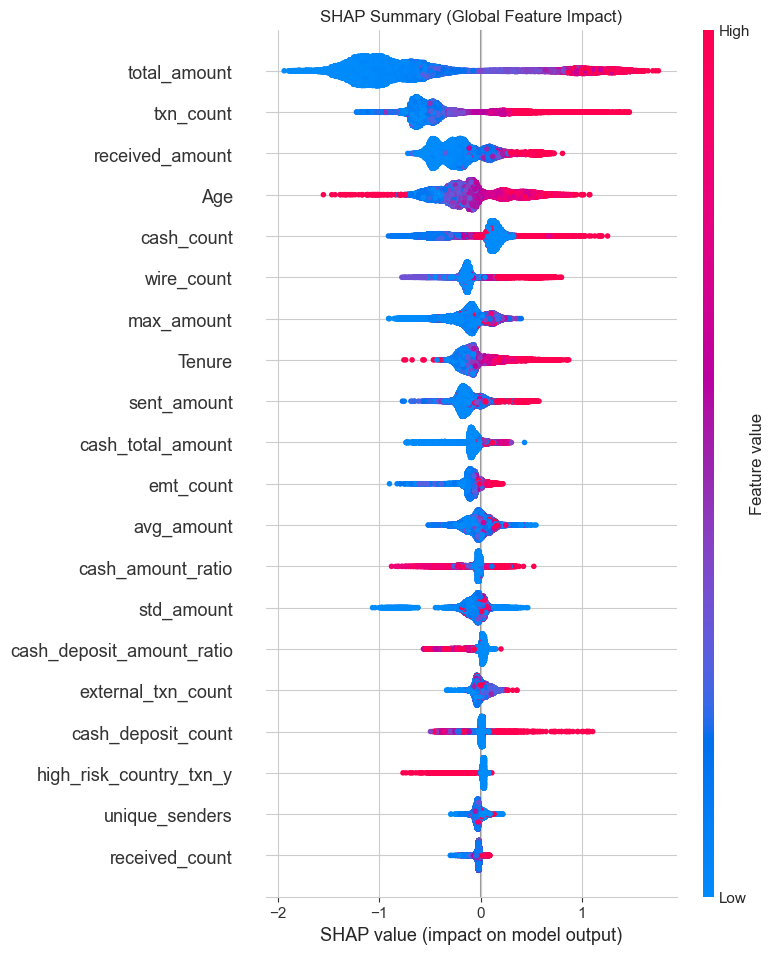

In [50]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary (Global Feature Impact)")
plt.show()

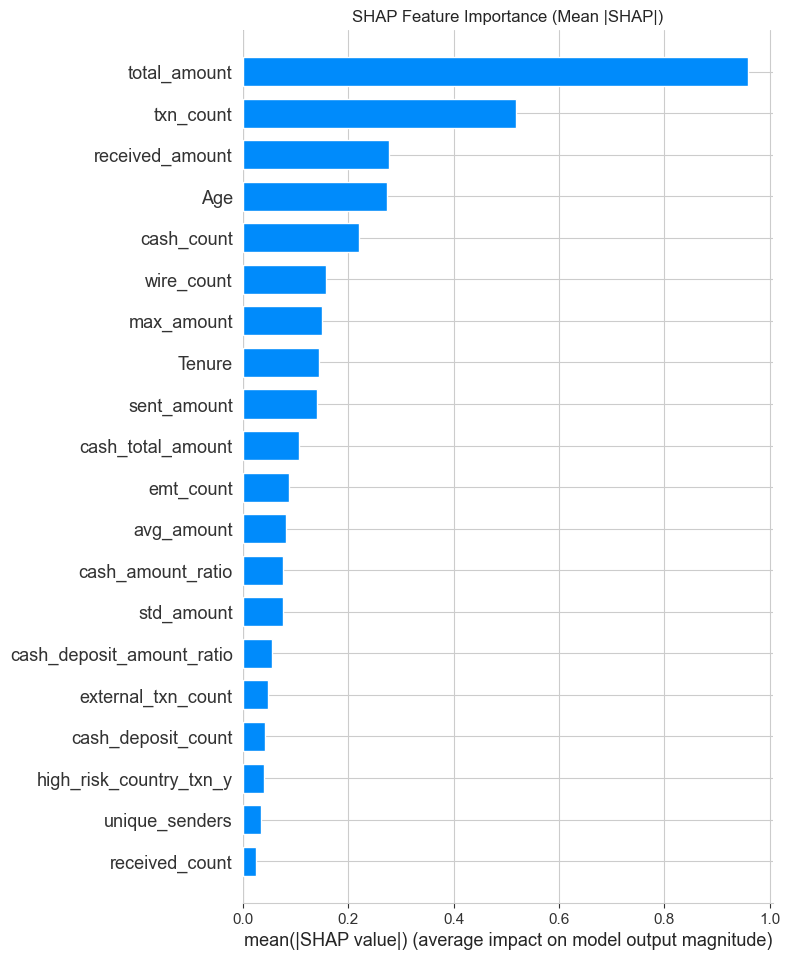

In [52]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|)")
plt.show()

In [54]:
# Top 10 features by mean absolute SHAP
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:10]
top_features = X_test.columns[top_idx].tolist()

top_features

['total_amount',
 'txn_count',
 'received_amount',
 'Age',
 'cash_count',
 'wire_count',
 'max_amount',
 'Tenure',
 'sent_amount',
 'cash_total_amount']

Index chosen: 3374
Predicted AML probability: 0.997849


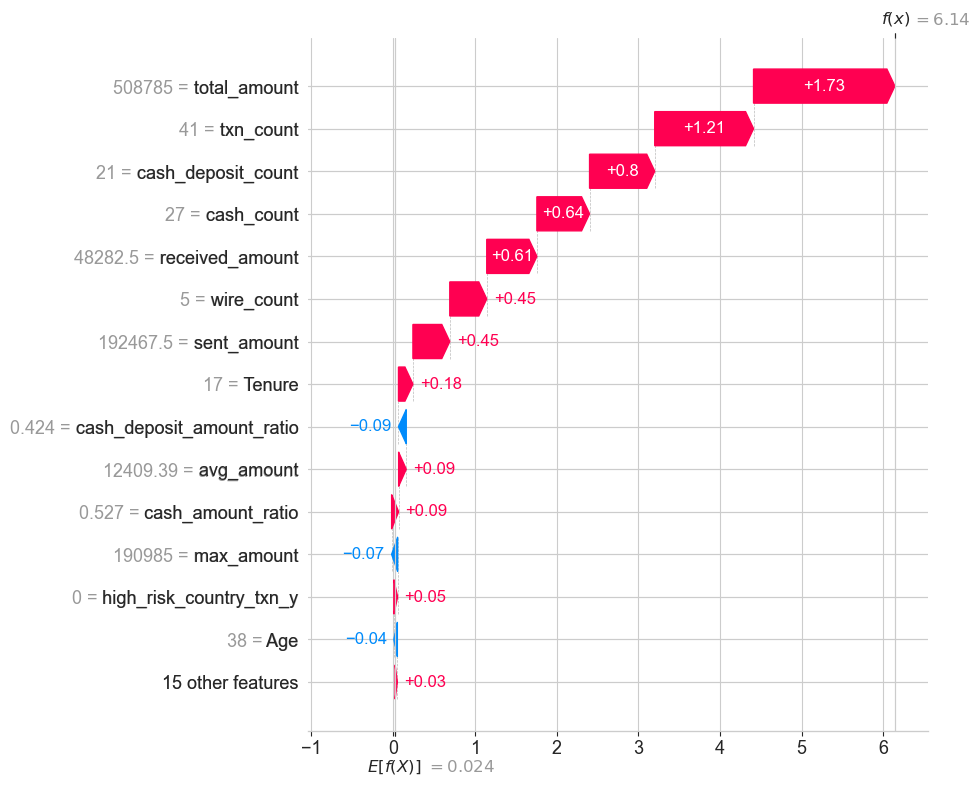

In [57]:
# Choose a transaction predicted highest risk
pred_proba = model_to_explain.predict_proba(X_test)[:, 1]
i = int(np.argmax(pred_proba))

print("Index chosen:", i)
print("Predicted AML probability:", pred_proba[i])

# Waterfall plot (single prediction explanation)
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=base_value,
        data=X_test.iloc[i],
        feature_names=X_test.columns
    ),
    max_display=15
)

In [59]:
# Force plot (works best in notebooks)
shap.initjs()

shap.force_plot(
    base_value,
    shap_values[i],
    X_test.iloc[i],
    feature_names=X_test.columns
)

In [61]:
# Create a reason-codes view for top N high-risk cases
N = 20
top_cases = np.argsort(pred_proba)[::-1][:N]

rows = []
for idx in top_cases:
    contrib = pd.Series(shap_values[idx], index=X_test.columns).sort_values(key=np.abs, ascending=False)
    top_reasons = contrib.head(5)
    rows.append({
        "row_index": int(idx),
        "pred_aml_prob": float(pred_proba[idx]),
        "reason_1": f"{top_reasons.index[0]} ({top_reasons.iloc[0]:.3f})",
        "reason_2": f"{top_reasons.index[1]} ({top_reasons.iloc[1]:.3f})",
        "reason_3": f"{top_reasons.index[2]} ({top_reasons.iloc[2]:.3f})",
        "reason_4": f"{top_reasons.index[3]} ({top_reasons.iloc[3]:.3f})",
        "reason_5": f"{top_reasons.index[4]} ({top_reasons.iloc[4]:.3f})",
    })

reason_codes = pd.DataFrame(rows).sort_values("pred_aml_prob", ascending=False)
reason_codes

,row_index,pred_aml_prob,reason_1,reason_2,reason_3,reason_4,reason_5
0,3374,0.997849,total_amount (1.729),txn_count (1.209),cash_deposit_count (0.797),cash_count (0.645),received_amount (0.614)
1,23771,0.997385,total_amount (1.610),txn_count (1.454),cash_deposit_count (0.956),cash_count (0.916),received_amount (0.583)
2,12760,0.997047,total_amount (1.463),txn_count (1.265),cash_count (0.665),received_amount (0.585),wire_count (0.451)
3,7281,0.996944,total_amount (1.515),txn_count (1.353),cash_count (0.858),cash_deposit_count (0.836),received_amount (0.492)
4,16419,0.996759,total_amount (1.496),txn_count (1.317),cash_count (0.858),cash_deposit_count (0.739),received_amount (0.587)
5,21767,0.996618,total_amount (1.536),txn_count (1.179),received_amount (0.570),cash_count (0.523),wire_count (0.453)
6,27543,0.996614,total_amount (1.653),txn_count (1.437),cash_count (0.921),cash_deposit_count (0.876),wire_count (0.480)
7,3620,0.996613,total_amount (1.536),txn_count (1.416),cash_count (0.823),cash_deposit_count (0.773),received_amount (0.578)
8,22014,0.996534,total_amount (1.493),txn_count (1.227),received_amount (0.597),cash_count (0.594),wire_count (0.514)
9,20927,0.996114,total_amount (1.530),txn_count (1.438),cash_deposit_count (0.866),cash_count (0.863),received_amount (0.546)


In [63]:
# SHAP value sum roughly corresponds to log-odds movement from base value
shap_sum = np.sum(shap_values, axis=1)

tmp = pd.DataFrame({
    "shap_sum": shap_sum,
    "y": y_test.values
})

tmp.groupby("y")["shap_sum"].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
0,33749.0,-2.302547,1.556579,-6.117008,-3.373475,-2.553849,-1.579401,5.083806
1,1092.0,2.229637,1.956347,-4.712545,1.303724,2.804351,3.553017,6.115690
